/home/nitin/miniconda3/envs/dl/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:818: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(
`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


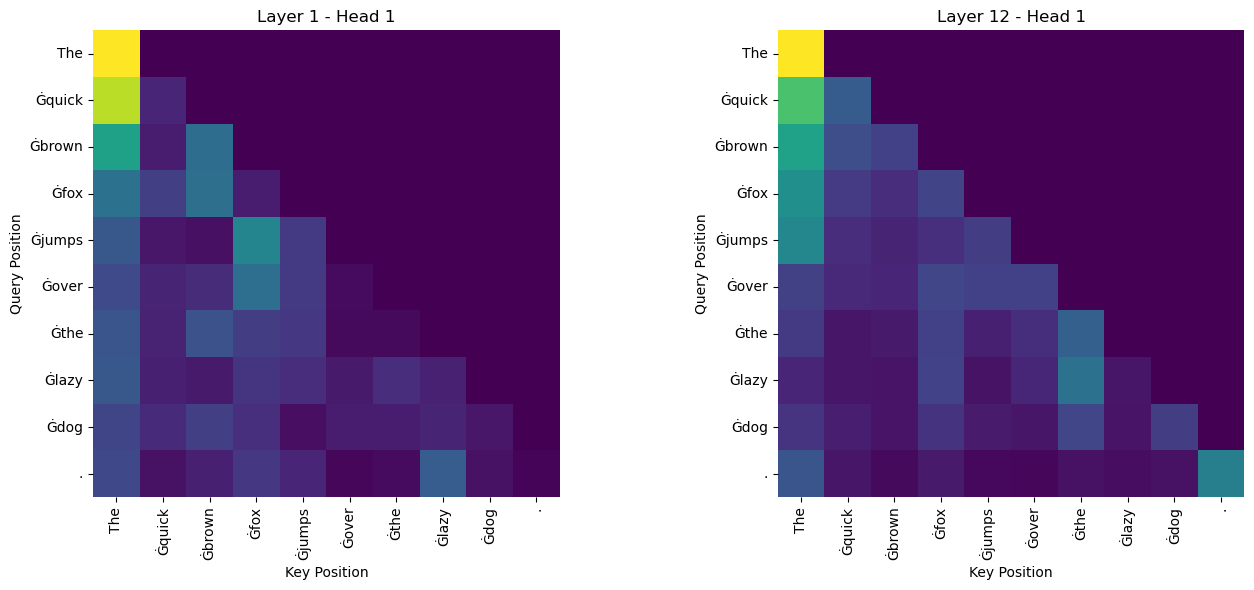

In [7]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Load a pretrained BERT model and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2", output_attentions=True)
model.eval()

# Define an input sentence
sentence = "The quick brown fox jumps over the lazy dog."

# Tokenize and prepare input
inputs = tokenizer(sentence, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

# Extract attention weights
attentions = outputs.attentions  # List of [batch_size, num_heads, seq_len, seq_len]

# We'll visualize layer 1 and 12 (first and last layers), for head 0
layer_indices = [0, 11]  # 0-based indexing
head_index = 0

# Prepare data for plotting
attention_maps = [attentions[i][0, head_index].numpy() for i in layer_indices]
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

attention_titles = [f"Layer {i+1} - Head {head_index+1}" for i in layer_indices]

# Plot
fig, axes = plt.subplots(1, len(attention_maps), figsize=(14, 6))
for i, (attn, title) in enumerate(zip(attention_maps, attention_titles)):
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap="viridis", cbar=False, ax=axes[i], square=True)
    axes[i].set_title(title)
    axes[i].set_xlabel("Key Position")
    axes[i].set_ylabel("Query Position")

plt.tight_layout()
plt.show()
